In [3]:
import os
from pyspark.sql import SparkSession

base_dir = r"E:\BIGDATA\data\parquet"
temp_dir = os.path.join(base_dir, "spark_temp")
os.makedirs(temp_dir, exist_ok=True)

spark = (
    SparkSession.builder
    .appName("PCA_feature")
    .master("local[*]")
    .config("spark.hadoop.fs.defaultFS", "file:///")
    .config("spark.local.dir", temp_dir)
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)
spark

In [4]:
parquet_path = r"E:\BIGDATA\data\parquet\cic_ddos_2019_10gb_cleaned.parquet"

df_raw = spark.read.parquet(parquet_path)
df_raw.printSchema()

root
 |-- label: string (nullable = true)
 |-- source_port: integer (nullable = true)
 |-- destination_port: integer (nullable = true)
 |-- protocol: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- flow_duration: long (nullable = true)
 |-- total_fwd_packets: integer (nullable = true)
 |-- total_backward_packets: integer (nullable = true)
 |-- total_length_of_fwd_packets: double (nullable = true)
 |-- total_length_of_bwd_packets: double (nullable = true)
 |-- fwd_packet_length_max: double (nullable = true)
 |-- fwd_packet_length_min: double (nullable = true)
 |-- fwd_packet_length_mean: double (nullable = true)
 |-- fwd_packet_length_std: double (nullable = true)
 |-- bwd_packet_length_max: double (nullable = true)
 |-- bwd_packet_length_min: double (nullable = true)
 |-- bwd_packet_length_mean: double (nullable = true)
 |-- bwd_packet_length_std: double (nullable = true)
 |-- flow_bytes_per_s: double (nullable = true)
 |-- flow_packets_per_s: double (nullabl

In [5]:
from pyspark.sql import functions as F


df = df_raw


print("Rows:", df.count())
df.show(5, truncate=False)

Rows: 24207109
+----------+-----------+----------------+--------+--------------------------+-------------+-----------------+----------------------+---------------------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+----------------+------------------+-------------+------------+------------+------------+-------------+------------+-----------+-----------+-----------+-------------+------------+-----------+-----------+-----------+-------------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------+------------------+-----------------+----------------------+--------------+--------------+--------------+--------------+--------------+-----------------+-------------------+--------------------+--------------------+-------------------+-------------------+-----------------+---------

In [ ]:
raw_vis_cols = [
    "flow_bytes_per_s",
    "flow_packets_per_s",
    "label"
]

raw_sample = (
    df_raw
    .select(raw_vis_cols)
    .sample(fraction=0.01, seed=42)
    .limit(10000)
    .toPandas()
)


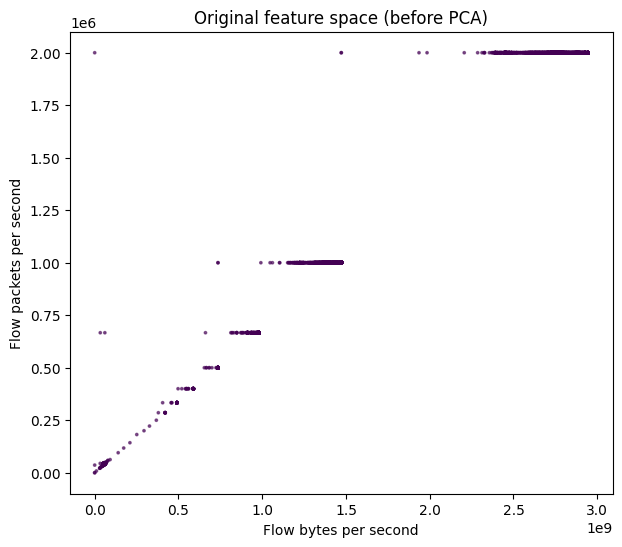

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(
    raw_sample["flow_bytes_per_s"],
    raw_sample["flow_packets_per_s"],
    c=(raw_sample["label"] != "BENIGN"),
    s=3,
    alpha=0.6
)

plt.xlabel("Flow bytes per second")
plt.ylabel("Flow packets per second")
plt.title("Original feature space (before PCA)")
plt.show()


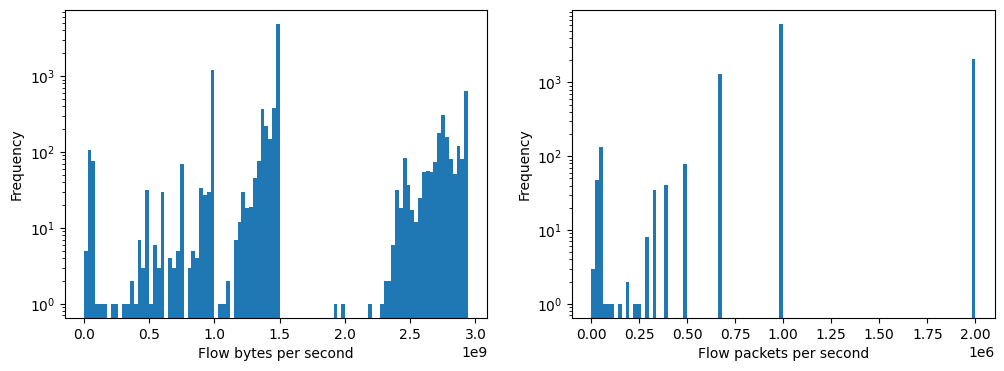

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(
    raw_sample["flow_bytes_per_s"],
    bins=100,
    log=True
)
plt.xlabel("Flow bytes per second")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(
    raw_sample["flow_packets_per_s"],
    bins=100,
    log=True
)
plt.xlabel("Flow packets per second")
plt.ylabel("Frequency")

plt.show()


In [6]:
exclude_cols = ["label", "timestamp", "simillarhttp"]

feature_cols = [
    c for c, t in df_raw.dtypes
    if c not in exclude_cols and t != "string"
]
print("Feature columns:", feature_cols)

Feature columns: ['source_port', 'destination_port', 'protocol', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes_per_s', 'flow_packets_per_s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets_per_s', 'bwd_packets_per_s', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'syn_flag_count', 'rst_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_flag_count', 'down_per_up_ratio', 'average_packet_size'

In [7]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

In [8]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_vec = assembler.transform(df_raw).select("features")


In [9]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vec)
df_scaled = scaler_model.transform(df_vec).select("scaled_features")


In [10]:
pca_full = PCA(
    k=len(feature_cols),
    inputCol="scaled_features",
    outputCol="pca_full"
)


In [11]:
pca_full_model = pca_full.fit(df_scaled)


In [12]:
import numpy as np
explained = pca_full_model.explainedVariance.toArray()
cum_var = np.cumsum(explained)


In [14]:
k_80 = int(np.argmax(cum_var >= 0.80)) + 1
k_90 = int(np.argmax(cum_var >= 0.90)) + 1
k_95 = int(np.argmax(cum_var >= 0.95)) + 1

k_80, k_90, k_95


(15, 21, 25)

In [ ]:
spark.stop()

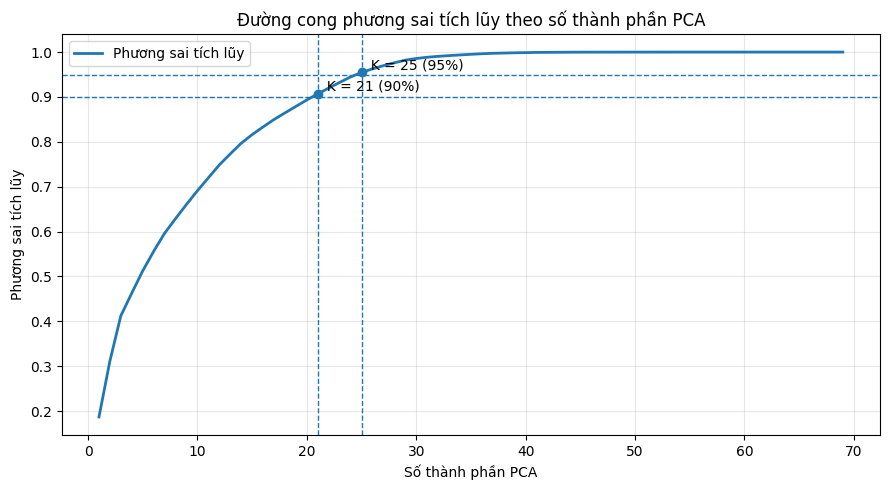

In [16]:
import numpy as np
import matplotlib.pyplot as plt

components = np.arange(1, len(cum_var) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    components,
    cum_var,
    linewidth=2,
    label="Phương sai tích lũy"
)

plt.axhline(0.90, linestyle="--", linewidth=1)
plt.axhline(0.95, linestyle="--", linewidth=1)

plt.axvline(21, linestyle="--", linewidth=1)
plt.axvline(25, linestyle="--", linewidth=1)

plt.scatter(
    [21, 25],
    [cum_var[20], cum_var[24]],
    zorder=5
)

plt.text(
    21,
    cum_var[20],
    "  K = 21 (90%)",
    va="bottom"
)

plt.text(
    25,
    cum_var[24],
    "  K = 25 (95%)",
    va="bottom"
)

plt.xlabel("Số thành phần PCA")
plt.ylabel("Phương sai tích lũy")
plt.title("Đường cong phương sai tích lũy theo số thành phần PCA")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
